In [45]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import random
import matplotlib.pyplot as plt
import random
from skimage.exposure import match_histograms
import openpyxl

In [46]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [47]:
CLINICAL_PATH = "/Users/taliacho/Downloads/Ranger/Bryan-Ranger/clinical_data/ABS_all_bw"
PHANTOM_PATH  = "/Users/taliacho/Downloads/Ranger/Bryan-Ranger/local_data/abs_neonatal_bw" 

N_CLINICAL_TRAIN = 270   #338 max, 8020 is 270 68
N_CLINICAL_TEST  = 68    

N_PHANTOM_TRAIN  = 270    #938 max, 8020 is 750 188
N_PHANTOM_TEST   = 0    

RANDOM_SEED = 42
IMG_SIZE    = (128, 128)

In [48]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        conv_out = self.conv(x)
        pooled = self.pool(conv_out)
        return conv_out, pooled

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.upconv(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [49]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = Encoder(3, 64)
        self.enc2 = Encoder(64, 128)
        self.enc3 = Encoder(128, 256)
        self.enc4 = Encoder(256, 512)

        self.bottleneck = ConvBlock(512, 1024)

        self.dec1 = Decoder(1024, 512)
        self.dec2 = Decoder(512, 256)
        self.dec3 = Decoder(256, 128)
        self.dec4 = Decoder(128, 64)

        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)

        b = self.bottleneck(p4)

        d1 = self.dec1(b, s4)
        d2 = self.dec2(d1, s3)
        d3 = self.dec3(d2, s2)
        d4 = self.dec4(d3, s1)

        out = self.final_conv(d4)
        return self.sigmoid(out)

In [50]:
class SegmentationDataset(Dataset):
    def __init__(self, folder_path, file_list, img_size=(128, 128), reference_image=None):
        self.folder_path     = folder_path
        self.img_size        = img_size
        self.image_files     = file_list
        self.reference_image = reference_image  # if set, histogram match to this

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file  = self.image_files[idx]
        mask_file = img_file.replace(".jpeg", "_m.jpeg")

        image = Image.open(os.path.join(self.folder_path, img_file)).convert("RGB").resize(self.img_size)
        mask  = Image.open(os.path.join(self.folder_path, mask_file)).convert("L").resize(self.img_size)

        image_np = np.array(image)

        # Match phantom histogram to clinical reference if provided
        if self.reference_image is not None:
            image_np = match_histograms(image_np, self.reference_image, channel_axis=-1).astype(np.uint8)

        image = torch.from_numpy(image_np / 255.0).permute(2, 0, 1).float()
        mask  = torch.from_numpy((np.array(mask) / 255.0 > 0.5).astype(np.float32)).unsqueeze(0)

        return image, mask

In [51]:
def sample_files(folder_path, n, seed=42):
    all_files = sorted([
        f for f in os.listdir(folder_path)
        if f.endswith(".jpeg") and not f.endswith("_m.jpeg")
    ])
    if n > len(all_files):
        raise ValueError(f"Requested {n} files but only {len(all_files)} available in {folder_path}")
    random.seed(seed)
    return random.sample(all_files, n)

In [52]:
# Sample from each source (train + test counts must not exceed available files)
clinical_train_files = sample_files(CLINICAL_PATH, N_CLINICAL_TRAIN, seed=RANDOM_SEED)

# For test, exclude files already used in train to avoid leakage
all_clinical = sorted([f for f in os.listdir(CLINICAL_PATH) if f.endswith(".jpeg") and not f.endswith("_m.jpeg")])
clinical_remaining = [f for f in all_clinical if f not in clinical_train_files]
random.seed(RANDOM_SEED + 1)
clinical_test_files = random.sample(clinical_remaining, N_CLINICAL_TEST)

phantom_train_files = sample_files(PHANTOM_PATH, N_PHANTOM_TRAIN, seed=RANDOM_SEED)
all_phantom = sorted([f for f in os.listdir(PHANTOM_PATH) if f.endswith(".jpeg") and not f.endswith("_m.jpeg")])
phantom_remaining = [f for f in all_phantom if f not in phantom_train_files]
random.seed(RANDOM_SEED + 2)
phantom_test_files = random.sample(phantom_remaining, N_PHANTOM_TEST)


# Reference image for histogram matching
reference_image = np.array(
    Image.open(os.path.join(CLINICAL_PATH, clinical_train_files[0]))
    .convert("RGB")
    .resize(IMG_SIZE)
)

# Build datasets
train_dataset = ConcatDataset([
    SegmentationDataset(CLINICAL_PATH, clinical_train_files, IMG_SIZE),
    SegmentationDataset(PHANTOM_PATH,  phantom_train_files,  IMG_SIZE, reference_image=reference_image),
])

test_dataset = ConcatDataset([
    SegmentationDataset(CLINICAL_PATH, clinical_test_files, IMG_SIZE),
    SegmentationDataset(PHANTOM_PATH,  phantom_test_files,  IMG_SIZE, reference_image=reference_image),
])


train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False)

print(f"Train: {N_CLINICAL_TRAIN} clinical + {N_PHANTOM_TRAIN} phantom = {len(train_dataset)} total")
print(f"Test:  {N_CLINICAL_TEST} clinical + {N_PHANTOM_TEST} phantom = {len(test_dataset)} total")


Train: 270 clinical + 270 phantom = 540 total
Test:  68 clinical + 0 phantom = 68 total


In [53]:
def dice_coefficient(preds, targets, smooth=1e-6):
    preds   = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)


In [54]:
model     = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.RMSprop(model.parameters(), lr=1e-4)
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = total_dice = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss    = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_coefficient(outputs > 0.5, masks).item()

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {total_loss/len(train_loader):.4f}, "
          f"Dice: {total_dice/len(train_loader):.4f}")


Epoch 1/5, Loss: 0.3283, Dice: 0.7079
Epoch 2/5, Loss: 0.2058, Dice: 0.8295
Epoch 3/5, Loss: 0.1642, Dice: 0.8522
Epoch 4/5, Loss: 0.1477, Dice: 0.8690
Epoch 5/5, Loss: 0.1382, Dice: 0.8730


In [55]:
model.eval()
total_dice = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        preds = (model(images) > 0.5).float()
        total_dice += dice_coefficient(preds, masks).item()

print(f"\nTest Dice Score: {total_dice / len(test_loader):.4f}")


Test Dice Score: 0.6143


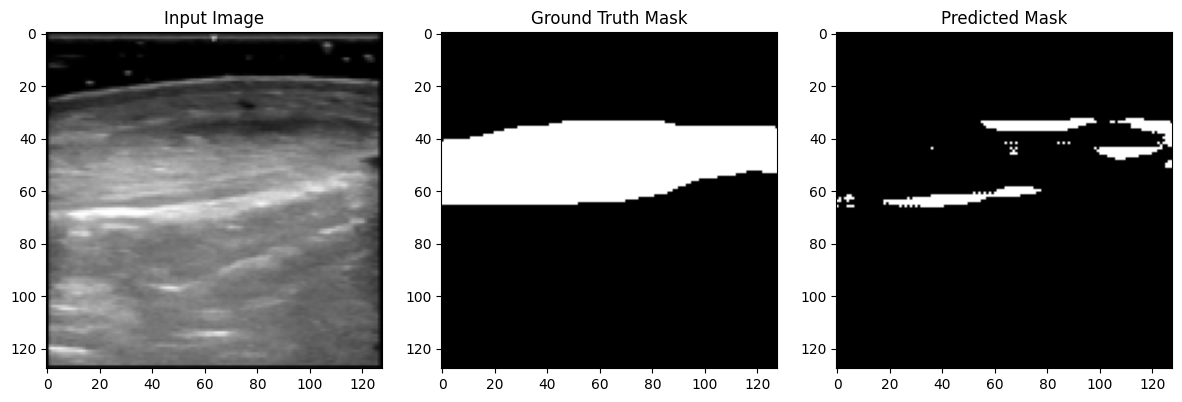

In [56]:
model.eval()
with torch.no_grad():
    rand_idx = random.randint(0, len(test_dataset) - 1)
    img, mask = test_dataset[rand_idx]
    img_input = img.unsqueeze(0).to(device)
    pred = model(img_input).cpu().numpy()[0, 0]
    pred_bin = (pred > 0.5).astype(np.uint8) * 255

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0).cpu())
plt.title("Input Image")
plt.subplot(1, 3, 2)
plt.imshow(mask[0].cpu(), cmap='gray')
plt.title("Ground Truth Mask")
plt.subplot(1, 3, 3)
plt.imshow(pred_bin, cmap='gray')
plt.title("Predicted Mask")
plt.tight_layout()
plt.show()

In [57]:
print(f"\n--- Dataset Summary ---")
print(f"Train: {N_CLINICAL_TRAIN} clinical + {N_PHANTOM_TRAIN} phantom = {len(train_dataset)} total")
print(f"Test:  {N_CLINICAL_TEST} clinical + {N_PHANTOM_TEST} phantom = {len(test_dataset)} total")


--- Dataset Summary ---
Train: 270 clinical + 270 phantom = 540 total
Test:  68 clinical + 0 phantom = 68 total


In [58]:
# Evaluate clinical test only
clinical_test_dataset = SegmentationDataset(CLINICAL_PATH, clinical_test_files, IMG_SIZE)
clinical_test_loader  = DataLoader(clinical_test_dataset, batch_size=1, shuffle=False)

model.eval()
total_dice = 0
with torch.no_grad():
    for images, masks in clinical_test_loader:
        images, masks = images.to(device), masks.to(device)
        preds = (model(images) > 0.5).float()
        total_dice += dice_coefficient(preds, masks).item()
print(f"Clinical-only Test Dice: {total_dice / len(clinical_test_loader):.4f}")

# # Evaluate phantom test only
# phantom_test_dataset = SegmentationDataset(PHANTOM_PATH, phantom_test_files, IMG_SIZE, reference_image=reference_image)
# phantom_test_loader  = DataLoader(phantom_test_dataset, batch_size=1, shuffle=False)
 
# total_dice = 0
# with torch.no_grad():
#     for images, masks in phantom_test_loader:
#         images, masks = images.to(device), masks.to(device)
#         preds = (model(images) > 0.5).float()
#         total_dice += dice_coefficient(preds, masks).item()
# print(f"Phantom-only Test Dice:  {total_dice / len(phantom_test_loader):.4f}")

Clinical-only Test Dice: 0.6143


In [62]:
import csv

# ── Calculate pixel area of predicted masks ───

print("\n--- Calculating predicted mask pixel areas ---")

model.eval()
results = []

with torch.no_grad():
    for idx in range(len(clinical_test_dataset)):
        img, mask = clinical_test_dataset[idx]
        img_input = img.unsqueeze(0).to(device)

        # Get prediction
        pred     = model(img_input).cpu().numpy()[0, 0]
        pred_bin = (pred > 0.5).astype(np.uint8)

        # Count foreground pixels
        pixel_area = int(pred_bin.sum())

        # Get filename
        filename = clinical_test_files[idx]

        results.append({
            "filename":   filename,
            "pixel_area": pixel_area
        })

        print(f"{filename}: {pixel_area} pixels")

# ── Save to CSV ───────────────────────────────

output_path = "predicted_mask_areas.csv"

with open(output_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Filename", "Predicted Pixel Area"])
    for r in results:
        writer.writerow([r["filename"], r["pixel_area"]])

print(f"\nSaved to {output_path}")


--- Calculating predicted mask pixel areas ---
25061918_AB2_R.jpeg: 3299 pixels
c_45092718_AB4_R.jpeg: 3376 pixels
c_01111517_AB3_R.jpeg: 3032 pixels
capture_5_2023-11-02T10-08-57.jpeg: 1370 pixels
capture_10_2024-03-04T10-30-17.jpeg: 1376 pixels
c_58041919_AB3_R.jpeg: 3308 pixels
c_6121817_AB1_R.jpeg: 2464 pixels
capture_1_2024-06-03T08-49-32.jpeg: 994 pixels
26061918_AB4_R.jpeg: 2247 pixels
c_35080318_AB2_R.jpeg: 6128 pixels
c_5120817_AB4_R.jpeg: 2588 pixels
c_36082218_AB2_R.jpeg: 3334 pixels
capture_4_2024-03-18T16-26-54.jpeg: 162 pixels
20052118_AB4_R.jpeg: 2700 pixels
c_36082218_AB3_R.jpeg: 3553 pixels
c_23061118_AB7_R.jpeg: 2843 pixels
capture_9_2024-03-04T10-30-17.jpeg: 1588 pixels
c_17042418_AB1_R.jpeg: 3077 pixels
c_55022619_AB1_R.jpeg: 3923 pixels
c_44091318_AB4_R.jpeg: 521 pixels
capture_2_2024-03-05T11-02-15.jpeg: 0 pixels
c_17042418_AB3_R.jpeg: 2524 pixels
42091218_AB2_R.jpeg: 2370 pixels
25061918_AB1_R.jpeg: 1035 pixels
capture_8_2024-04-16T04-18-04.jpeg: 1290 pixels
340